In [23]:
import polars as pl
from pathlib import Path

# data
DATA_DIR = Path("../../data_pipeline/wbaserunners/D1/2026")
lf = (
    pl.scan_parquet(str(DATA_DIR / "**/*.parquet"))
    .select([
        "GameID", "Inning", "Top/Bottom", "PlayResult", "RunsScored", 
        "Direction", "ExitSpeed", "Angle", "re288_state"
    ])
)
df = lf.collect()

# run expectancy matrix
REM = Path("../../data_pipeline/re_matrices/re288_matrix.parquet")
rem = pl.read_parquet(REM)
rem = rem.filter((pl.col("Level") == "D1") & (pl.col("year") == "2026"))

### Cleaning for the events that we want ###
# Will loop for it eventually but we'll just work with 2026. 

# 1. Calculate the delta for each batted ball event
df = (df.
    # shifting so we have a before and after re288 state
    with_columns(
        pl.col("re288_state")
        .shift(-1)
        .over(["GameID", "Inning", "Top/Bottom"])
        .alias("next_re288_state")
    )
    # mapping the re value to the before column and making a new column
    .join(
        rem.select(
            "re288_state",
            pl.col("run_expectancy").alias("re_before")
        ),
        on="re288_state",
        how="left"
    ) 
    # mapping the re value to the after column and making a new column
    .join(
        rem.select(
            pl.col("re288_state").alias("next_re288_state"),
            pl.col("run_expectancy").alias("re_after")
        ),
        on="next_re288_state",
        how="left"
    )
    .with_columns(pl.col("re_after").fill_null(0))
    # summing and adding new column 
    .with_columns(
        (
            pl.col("RunsScored")
            + pl.col("re_after")
            - pl.col("re_before")
        ).alias("run_delta")
    )
)

# 2. Filter for events that have exit_speed and Launch angle
df = df.filter((pl.col("ExitSpeed").is_not_null()) & (pl.col("Angle").is_not_null()))

# 3. Drop certain results in batted ball profile
drop_columns = ["Error", "Sacrifice", "StolenBase", "FieldersChoice", "CaughtStealing", "Undefined"]
df = df.filter(~pl.col("PlayResult").is_in(drop_columns))

# 4. For each batted ball event find the average run delta
bbe = df["PlayResult"].unique().to_list()
avg_run_values = (df
    .group_by("PlayResult")
    .agg(
        pl.col("run_delta").mean().alias("avg_run_delta")
    )
    .sort("avg_run_delta", descending=True)
)

In [24]:
# Contact Quality Model
# Map the expected outcome of a batted ball (EV, LA) to the linear weights of each outcome 

import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors 
from itertools import product

N_CLASSES = 5

### Core Components 

def neighbor_labels_sorted(X_ref, y_ref, X_query, max_k):
    """Labels of each query point's max_k nearest neighbors, nearest-first.
 
    ONE KD-tree search per call. Because kneighbors returns neighbors sorted by
    distance, the k nearest for any smaller k are just the first k columns --
    so a whole grid of k values costs a single search, not one search per k.
    """
    nn = NearestNeighbors(n_neighbors=max_k)
    nn.fit(X_ref)
    _, idx = nn.kneighbors(X_query)          # (n_query, max_k), sorted ascending
    return y_ref[idx]                       # (n_query, max_k)

def smoothed_proba(neighbor_lab, k, alpha, n_classes=N_CLASSES):
    """Laplace-smoothed class probabilities from the first k neighbors.
 
    p_class = (count_class + alpha) / (k + alpha * C)
 
    This is a Dirichlet(alpha,...) posterior: every class keeps nonzero mass,
    encoding the true prior that no launch condition makes any outcome strictly
    impossible. Rows sum to 1; the floor is alpha/(k + alpha*C).
    """
    sub = neighbor_lab[:, :k]                                      # k nearest
    counts = np.stack([(sub == c).sum(axis=1)
                       for c in range(n_classes)], axis=1).astype(float)
    return (counts + alpha) / (k + alpha * n_classes)

def mean_log_loss(proba, y_true):
    """Multiclass log-loss = mean of -log(prob assigned to the TRUE class).
 
    proba is already smoothed, so no clipping/epsilon games -- we know the floor.
    """
    p_true = proba[np.arange(len(y_true)), y_true]
    return -np.log(p_true).mean()


### Cross validation and arriving at optimal k, alpha values

def cv_select(X_tr, y_tr, k_grid, alpha_grid, n_splits=5, seed=0):
    """Stratified k-fold CV over the *Cartesian product* of k and alpha.
 
    Loop structure (outer -> inner):
        1. (k, alpha) grid   -- every pair is one candidate configuration
        2. k-fold CV         -- the engine that turns a pair into one score
        3. balls in the fold -- query, smooth, accumulate log-loss
 
    Stratified folds keep rare classes (3B, HR) present in every fold.
    Returns {(k, alpha): mean_cv_log_loss} and the argmin pair.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    max_k = max(k_grid)
    scores = {(k, a): 0.0 for k, a in product(k_grid, alpha_grid)}
 
    for train_idx, val_idx in skf.split(X_tr, y_tr):     # Loop 2: folds
        X_ref, y_ref = X_tr[train_idx], y_tr[train_idx]
        X_val, y_val = X_tr[val_idx],   y_tr[val_idx]
 
        # one neighbor search per fold, at the largest k in the grid
        lab = neighbor_labels_sorted(X_ref, y_ref, X_val, max_k)
 
        for k in k_grid:                                  # Loop 1a: k
            for alpha in alpha_grid:                       # Loop 1b: alpha
                proba = smoothed_proba(lab, k, alpha)      # Loop 3 inside
                scores[(k, alpha)] += mean_log_loss(proba, y_val)
 
    for key in scores:                                    # average over folds
        scores[key] /= n_splits
 
    best = min(scores, key=scores.get)
    return scores, best

### Fit and Predict

def fit_contact_model(X, y, linear_weights, k_grid, alpha_grid,
                      test_size=0.25, n_splits=5, seed=0):
    """Lock a test set, standardize, CV-select (k, alpha), report honest loss."""
    # (1) split off a TEST set ONCE -- never used for selection
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed)
 
    # (2) standardize EV/LA so Euclidean distance doesn't mix mph and degrees.
    #     Fit on TRAIN only. (Strict rigor would refit the scaler inside each
    #     CV fold; for two stable physical axes the leakage is negligible.)
    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_te_s = scaler.transform(X_te)
 
    # (3+4) joint (k, alpha) search by stratified CV on the training set
    scores, (best_k, best_alpha) = cv_select(
        X_tr_s, y_tr, k_grid, alpha_grid, n_splits=n_splits, seed=seed)
 
    # (5) honest test-set log-loss; reference set = ALL training data
    lab_te = neighbor_labels_sorted(X_tr_s, y_tr, X_te_s, best_k)
    proba_te = smoothed_proba(lab_te, best_k, best_alpha)
    test_loss = mean_log_loss(proba_te, y_te)
 
    return {
        "scaler": scaler,
        "X_ref": X_tr_s, "y_ref": y_tr,        # reference set for future queries
        "best_k": best_k, "best_alpha": best_alpha,
        "cv_scores": scores, "test_log_loss": test_loss,
        "linear_weights": np.asarray(linear_weights, dtype=float),
    }

def predict_proba(model, X_new):
    """P(outcome | EV, LA) for new batted balls -> (n, 5)."""
    Xs = model["scaler"].transform(np.atleast_2d(np.asarray(X_new, float)))
    lab = neighbor_labels_sorted(model["X_ref"], model["y_ref"],
                                 Xs, model["best_k"])
    return smoothed_proba(lab, model["best_k"], model["best_alpha"])

def predict_xrv(model, X_new):
    """Expected run value on contact -> (n,). This is the Stuff+ target."""
    return predict_proba(model, X_new) @ model["linear_weights"]

In [25]:
label_map = {
    "Out": 0, "Single": 1, "Double": 2, "Triple": 3, "HomeRun": 4,
}

X = df.select(["ExitSpeed", "Angle", "Direction"]).to_numpy().astype(float)
y = df["PlayResult"].replace_strict(label_map, return_dtype=pl.Int64).to_numpy()

lin_weights = [-0.399158, 0.599045, 0.906232, 1.133141, 1.415439] # avg run deltas of outs, 1b, 2b, 3b, hr

k_grid = [25, 50, 100, 200, 400, 800, 2000]
alpha_grid = [0.1, 0.5, 1.0, 2.0, 5.0]

model = fit_contact_model(X, y, lin_weights, k_grid, alpha_grid)

print(f"best (k, alpha) = ({model['best_k']}, {model['best_alpha']})")
print(f"held-out test log-loss = {model['test_log_loss']:.4f}\n")

print("CV log-loss grid (rows = k, cols = alpha):")
print("       " + "".join(f"a={a:<7}" for a in alpha_grid))

for k in k_grid:
        row = "".join(f"{model['cv_scores'][(k, a)]:<9.4f}" for a in alpha_grid)
        print(f"  k={k:<4} {row}")

print("\nsanity-check xRV for specific batted balls:")
probes = {
    "barrel          (105, 25, -15)": [105, 25, -15],   # pulled fly — classic HR
    "gap shot        (102, 24, -20)": [102, 24, -20],   # left-center gap drive
    "weak grounder   ( 85,-10, -25)": [85, -10, -25],   # pulled grounder, SS/3B hole
    "popup           ( 70, 45,  +5)": [70, 45, 5],      # near-vertical, slight 1B side
}

for label, ball in probes.items():
        xrv = predict_xrv(model, ball)[0]
        print(f"  {label:>26} -> xRV = {xrv:+.3f}")

best (k, alpha) = (200, 0.1)
held-out test log-loss = 0.5823

CV log-loss grid (rows = k, cols = alpha):
       a=0.1    a=0.5    a=1.0    a=2.0    a=5.0    
  k=25   0.6161   0.6337   0.6709   0.7435   0.9097   
  k=50   0.5961   0.6042   0.6233   0.6639   0.7731   
  k=100  0.5868   0.5906   0.5998   0.6206   0.6831   
  k=200  0.5858   0.5876   0.5919   0.6021   0.6346   
  k=400  0.5912   0.5921   0.5942   0.5990   0.6151   
  k=800  0.6036   0.6041   0.6051   0.6074   0.6150   
  k=2000 0.6330   0.6332   0.6336   0.6345   0.6373   

sanity-check xRV for specific batted balls:
  barrel          (105, 25, -15) -> xRV = +1.102
  gap shot        (102, 24, -20) -> xRV = +0.944
  weak grounder   ( 85,-10, -25) -> xRV = +0.003
  popup           ( 70, 45,  +5) -> xRV = -0.148


In [26]:
# Using our model to fill in all of the batted ball profiles of NCAA D1
def add_xrv(d, k, alpha):
    X  = d.select(["ExitSpeed", "Angle", "Direction"]).to_numpy().astype(float)
    y  = d["PlayResult"].replace_strict(label_map, return_dtype=pl.Int64).to_numpy()
    Xs = StandardScaler().fit_transform(X)              # standardize mph vs deg vs deg
    proba = smoothed_proba(neighbor_labels_sorted(Xs, y, Xs, k), k, alpha)
    return d.with_columns(pl.Series("xRV", proba @ lin_weights))

small = df.select(["ExitSpeed", "Angle", "Direction", "PlayResult", "run_delta"])
small = add_xrv(small, k=200, alpha=0.1)               # <- your k / alpha
small

ExitSpeed,Angle,Direction,PlayResult,run_delta,xRV
f64,f64,f64,str,f64,f64
99.72404,-5.177539,-16.016327,"""Out""",-0.34015,-0.225536
73.44755,10.447932,21.546426,"""Out""",-0.454778,0.073178
103.36356,26.673683,-16.538374,"""Out""",-0.123045,1.149378
88.00207,35.164395,3.875652,"""Out""",-0.223876,-0.383318
106.08154,16.754459,4.85212,"""Out""",-0.164659,0.321256
…,…,…,…,…,…
92.10268,-24.95623,-1.030129,"""Single""",0.551473,-0.027926
83.1983,1.674438,-11.862924,"""Out""",-0.262583,-0.167326
93.15253,-10.22107,41.796837,"""Out""",-0.383037,-0.108411


In [27]:
# Comparing the averages of the run_delta and the expected run value
# Hovering around zero is good
run_delta_mean = small["run_delta"].mean()
xrv_mean = small["xRV"].mean()

print(run_delta_mean - xrv_mean)

-0.003753451983788632


In [28]:
with pl.Config(tbl_cols=-1, tbl_width_chars=-1):
    print(df)

shape: (305_275, 13)
┌───────────────────────────────┬────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┬─────────────┬──────────────────┬───────────┬──────────┬───────────┐
│ GameID                        ┆ Inning ┆ Top/Bottom ┆ PlayResult ┆ RunsScored ┆ Direction  ┆ ExitSpeed ┆ Angle     ┆ re288_state ┆ next_re288_state ┆ re_before ┆ re_after ┆ run_delta │
│ ---                           ┆ ---    ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---         ┆ ---              ┆ ---       ┆ ---      ┆ ---       │
│ str                           ┆ i64    ┆ str        ┆ str        ┆ i64        ┆ f64        ┆ f64       ┆ f64       ┆ str         ┆ str              ┆ f64       ┆ f64      ┆ f64       │
╞═══════════════════════════════╪════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╪═════════════╪══════════════════╪═══════════╪══════════╪═══════════╡
│ 20260213-AbileneChristian-2   ┆ 1      ┆ T

In [29]:
# KNN model that maps EV/LA to probabilities of an event (out, single, etc.) 
rem

Level,year,re288_state,base_state,Outs,Balls,Strikes,n_obs,run_expectancy
str,str,str,str,i64,i64,i64,u32,f64
"""D1""","""2026""","""000|0|0-0""","""000""",0,0,0,116504,0.761193
"""D1""","""2026""","""000|0|0-1""","""000""",0,0,1,54494,0.68213
"""D1""","""2026""","""000|0|0-2""","""000""",0,0,2,26637,0.586965
"""D1""","""2026""","""000|0|1-0""","""000""",0,1,0,47201,0.839834
"""D1""","""2026""","""000|0|1-1""","""000""",0,1,1,44850,0.73893
…,…,…,…,…,…,…,…,…
"""D1""","""2026""","""111|2|2-1""","""111""",2,2,1,2388,1.082077
"""D1""","""2026""","""111|2|2-2""","""111""",2,2,2,2908,0.773728
"""D1""","""2026""","""111|2|3-0""","""111""",2,3,0,672,1.657738


In [30]:
with pl.Config(tbl_cols=-1, tbl_width_chars=-1):
    print(df)

shape: (305_275, 13)
┌───────────────────────────────┬────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┬─────────────┬──────────────────┬───────────┬──────────┬───────────┐
│ GameID                        ┆ Inning ┆ Top/Bottom ┆ PlayResult ┆ RunsScored ┆ Direction  ┆ ExitSpeed ┆ Angle     ┆ re288_state ┆ next_re288_state ┆ re_before ┆ re_after ┆ run_delta │
│ ---                           ┆ ---    ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---         ┆ ---              ┆ ---       ┆ ---      ┆ ---       │
│ str                           ┆ i64    ┆ str        ┆ str        ┆ i64        ┆ f64        ┆ f64       ┆ f64       ┆ str         ┆ str              ┆ f64       ┆ f64      ┆ f64       │
╞═══════════════════════════════╪════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╪═════════════╪══════════════════╪═══════════╪══════════╪═══════════╡
│ 20260213-AbileneChristian-2   ┆ 1      ┆ T

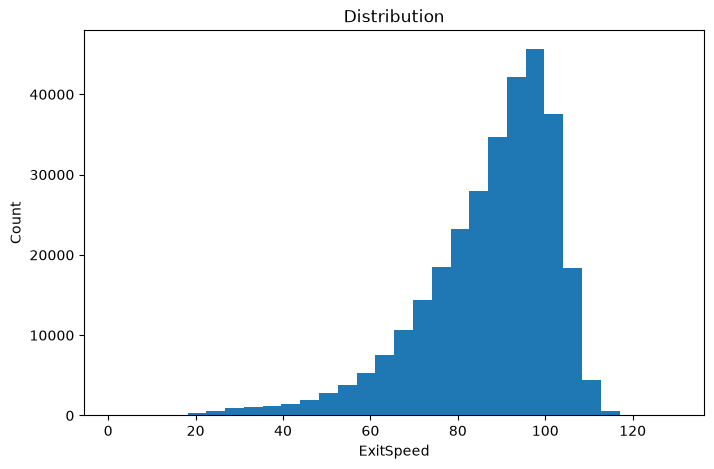

In [31]:
# making sure the ev distribution isn't stupid
import matplotlib.pyplot as plt
values = df["ExitSpeed"].drop_nulls().to_numpy()
plt.figure(figsize=(8, 5))
plt.hist(values, bins=30)
plt.xlabel("ExitSpeed")
plt.ylabel("Count")
plt.title("Distribution")
plt.show()